<a href="https://colab.research.google.com/github/HarithaSuneesh/csv.py/blob/main/3rdproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## SUPERVISED LEARNING

In [4]:
import pandas as pd
data = pd.read_csv("https://drive.google.com/uc?export=download&id=1zng6KpOBIEOMGQbn1jKYZECdkAGqyWB2")
data

,Unnamed: 0,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned (kcal)
0,0,56,Female,53.8,1.62,163.0,149.0,71.0,1.01,HIIT,22.1,3.5,3,1,20.4,9.5,0.847826,8.054348,437.7
1,1,46,Male,54.9,1.75,170.0,126.0,73.0,0.25,Yoga,19.9,3.4,3,0,18.0,3.0,0.546392,1.639175,22.5
2,2,32,Female,68.5,1.61,190.0,171.0,60.0,0.33,HIIT,20.4,2.7,3,1,26.5,9.5,0.853846,8.111538,183.4
3,3,25,Male,98.8,1.86,189.0,135.0,69.0,0.78,Yoga,30.3,4.4,3,0,28.5,3.0,0.550000,1.650000,127.2
4,4,38,Male,95.5,1.71,176.0,138.0,66.0,0.55,Cardio,23.7,2.2,2,0,32.5,7.0,0.654545,4.581818,240.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14097,14097,18,Male,75.7,1.76,205.0,143.0,67.0,0.62,Yoga,23.3,3.7,4,1,24.3,3.0,0.550725,1.652174,77.5
14098,14098,54,Male,66.4,1.71,162.0,131.0,73.0,0.93,Cardio,15.0,2.7,3,1,22.7,7.0,0.651685,4.561798,281.7
14099,14099,23,Female,74.7,1.52,204.0,161.0,61.0,0.99,Strength,19.3,4.3,3,1,32.5,6.0,0.699301,4.195804,310.3
14100,14100,43,Male,70.8,1.69,171.0,154.0,55.0,1.01,HIIT,12.3,3.9,7,3,24.9,9.5,0.853448,8.107759,579.8


# To Check Null/Missing values

In [5]:

# Check for missing values in each column
missing_values = data.isnull().sum(axis=1)

# Display the total missing values per column
print("Missing values in each column:\n", missing_values)

# To see only columns that have missing values:
print("\nColumns with at least one missing value:\n", missing_values[missing_values > 0])

Missing values in each column:
 0        0
1        0
2        0
3        0
4        0
        ..
14097    0
14098    0
14099    0
14100    0
14101    0
Length: 14102, dtype: int64

Columns with at least one missing value:
 Series([], dtype: int64)


### Outlier detection and capping

In [6]:
print(data.columns.tolist())

['Unnamed: 0', 'Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI', 'Base_MET', 'HR_Intensity', 'Effective_MET', 'Calories_Burned (kcal)']


In [ ]:
data['Calories_Burned (kcal)'].describe()

,Calories_Burned (kcal)
count,14102.000000
mean,277.199610
std,165.404118
min,18.400000
25%,143.200000
50%,251.050000
75%,373.700000
max,719.450000


--- Outlier Detection ---
Lower Bound: 0
Upper Bound: 719.45


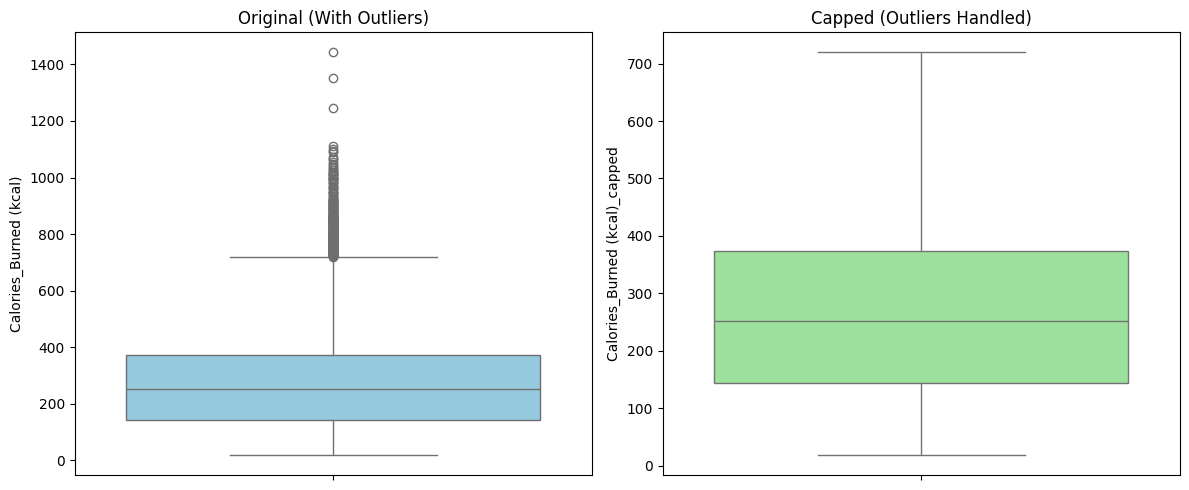

Outliers remaining after capping: 0
New column created: 'Calories_Burned (kcal)_capped'


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

target_col = 'Calories_Burned (kcal)'

# 1. Calculate IQR (Interquartile Range)
Q1 = data[target_col].quantile(0.25)
Q3 = data[target_col].quantile(0.75)
IQR = Q3 - Q1

# 2. Define Bounds
# Set lower limit strictly to 0
lower_bound = 0
# Alternatively, to keep IQR logic but prevent negative bounds, use:
# lower_bound = max(0, Q1 - 1.5 * IQR)

upper_bound = Q3 + 1.5 * IQR

print(f"--- Outlier Detection ---")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

# 3. Capping (Winsorization)
# .clip handles both upper and lower bounds automatically
data[target_col + '_capped'] = data[target_col].clip(lower=lower_bound, upper=upper_bound)

# 4. Visualization
plt.figure(figsize=(12, 5))

# Original Plot
plt.subplot(1, 2, 1)
sns.boxplot(y=data[target_col], color='skyblue')
plt.title('Original (With Outliers)')

# Capped Plot
plt.subplot(1, 2, 2)
sns.boxplot(y=data[target_col + '_capped'], color='lightgreen')
plt.title('Capped (Outliers Handled)')

plt.tight_layout()
plt.show()

# Verification
outliers_after = ((data[target_col + '_capped'] < lower_bound) |
                  (data[target_col + '_capped'] > upper_bound)).sum()

print(f"Outliers remaining after capping: {outliers_after}")
print("New column created: 'Calories_Burned (kcal)_capped'")

### Encoding Categorical Values

In [9]:
data['Gender'].unique()

array(['Female', 'Male'], dtype=object)

In [10]:
data['Workout_Type'].unique()

array(['HIIT', 'Yoga', 'Cardio', 'Mixed', 'Strength'], dtype=object)

In [ ]:
data.dtypes

,0
Unnamed: 0,int64
Age,int64
Gender,object
Weight (kg),float64
Height (m),float64
Max_BPM,float64
Avg_BPM,float64
Resting_BPM,float64
Session_Duration (hours),float64
Workout_Type,object


In [11]:
from sklearn.preprocessing import LabelEncoder

# Create a copy to avoid modifying the original dff if it's used elsewhere
data_label_encoded = data.copy()

# Initialize LabelEncoder
le = LabelEncoder()

# Apply Label Encoding to 'Gender' column
data_label_encoded['Gender_Encoded'] = le.fit_transform(data_label_encoded['Gender'])

# Apply Label Encoding to 'Workout_Type' column
data_label_encoded['Workout_Type_Encoded'] = le.fit_transform(data_label_encoded['Workout_Type'])

# Display the DataFrame with encoded columns
display(data_label_encoded)

,Unnamed: 0,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Workout_Type,...,Workout_Frequency (days/week),Experience_Level,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned (kcal),Calories_Burned (kcal)_capped,Gender_Encoded,Workout_Type_Encoded
0,0,56,Female,53.8,1.62,163.0,149.0,71.0,1.01,HIIT,...,3,1,20.4,9.5,0.847826,8.054348,437.7,437.7,0,1
1,1,46,Male,54.9,1.75,170.0,126.0,73.0,0.25,Yoga,...,3,0,18.0,3.0,0.546392,1.639175,22.5,22.5,1,4
2,2,32,Female,68.5,1.61,190.0,171.0,60.0,0.33,HIIT,...,3,1,26.5,9.5,0.853846,8.111538,183.4,183.4,0,1
3,3,25,Male,98.8,1.86,189.0,135.0,69.0,0.78,Yoga,...,3,0,28.5,3.0,0.550000,1.650000,127.2,127.2,1,4
4,4,38,Male,95.5,1.71,176.0,138.0,66.0,0.55,Cardio,...,2,0,32.5,7.0,0.654545,4.581818,240.7,240.7,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14097,14097,18,Male,75.7,1.76,205.0,143.0,67.0,0.62,Yoga,...,4,1,24.3,3.0,0.550725,1.652174,77.5,77.5,1,4
14098,14098,54,Male,66.4,1.71,162.0,131.0,73.0,0.93,Cardio,...,3,1,22.7,7.0,0.651685,4.561798,281.7,281.7,1,0
14099,14099,23,Female,74.7,1.52,204.0,161.0,61.0,0.99,Strength,...,3,1,32.5,6.0,0.699301,4.195804,310.3,310.3,0,3
14100,14100,43,Male,70.8,1.69,171.0,154.0,55.0,1.01,HIIT,...,7,3,24.9,9.5,0.853448,8.107759,579.8,579.8,1,1


# Feature scaling

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

feature_columns = [
    'Age', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM',
    'Session_Duration (hours)', 'Fat_Percentage', 'Water_Intake (liters)',
    'Workout_Frequency (days/week)', 'Experience_Level', 'BMI', 'Base_MET',
    'HR_Intensity', 'Effective_MET', 'Gender_Encoded', 'Workout_Type_Encoded'
]
x = data_label_encoded[feature_columns]
y = data_label_encoded['Calories_Burned (kcal)']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=4)

In [14]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [15]:
model.predict(x_test)
print(model.score(x_test,y_test))

0.9094180418444682


In [16]:
#Standard Scaler
from sklearn import metrics
import numpy as np
from sklearn.metrics import r2_score
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


model_standard = LinearRegression()
model_standard.fit(x_train_scaled, y_train)
y_pred_standard = model_standard.predict(x_test_scaled)


print("\nStandardScaler Results:")
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred_standard))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred_standard))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred_standard)))
print('R-squared:', r2_score(y_test, y_pred_standard))



StandardScaler Results:
Mean Absolute Error: 35.08463152537396
Mean Squared Error: 2815.8376055908
Root Mean Squared Error: 53.06446650622995
R-squared: 0.9094180418444681


In [ ]:
#Pickling-it saves as binary and only gives the trained model

import pickle as pkl
pkl.dump(model,open('model.pkl','wb'))#wb-write binary






In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Model Imports
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

# 1. Prepare Features and Target
feature_columns = [
    'Age', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM',
    'Session_Duration (hours)', 'Fat_Percentage', 'Water_Intake (liters)',
    'Workout_Frequency (days/week)', 'Experience_Level', 'BMI', 'Base_MET',
    'HR_Intensity', 'Effective_MET', 'Gender_Encoded', 'Workout_Type_Encoded'
]
x = data_label_encoded[feature_columns]
y = data_label_encoded['Calories_Burned (kcal)']

# 2. Split the Data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# 3. Scale the Data
# Crucial for KNN and SVR; Tree-based models will use unscaled x_train/x_test
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# --- 4. KNN Regressor ---
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(x_train_scaled, y_train)
y_pred_knn = knn_model.predict(x_test_scaled)

# --- 5. XGBoost Regressor ---
xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(x_train, y_train)
y_pred_xgb = xgb_model.predict(x_test)

# --- 6. Decision Tree Regressor ---
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(x_train, y_train)
y_pred_dt = dt_model.predict(x_test)

# --- 7. Random Forest Regressor ---
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)
y_pred_rf = rf_model.predict(x_test)

# --- 8. Support Vector Regression (SVR) ---
svr_model = SVR(kernel='rbf')
svr_model.fit(x_train_scaled, y_train)
y_pred_svr = svr_model.predict(x_test_scaled)

# --- 9. Final Evaluation Results ---
def evaluate(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"--- {name} Performance ---")
    print(f"MAE:  {mae:.2f}")
    print(f"MSE:  {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2:   {r2:.4f}\n")

# Run evaluation for all
evaluate("KNN", y_test, y_pred_knn)
evaluate("XGBoost", y_test, y_pred_xgb)
evaluate("Decision Tree", y_test, y_pred_dt)
evaluate("Random Forest", y_test, y_pred_rf)
evaluate("SVR", y_test, y_pred_svr)

--- KNN Performance ---
MAE:  29.61
MSE:  1788.40
RMSE: 42.29
R2:   0.9430

--- XGBoost Performance ---
MAE:  5.23
MSE:  61.80
RMSE: 7.86
R2:   0.9980

--- Decision Tree Performance ---
MAE:  8.44
MSE:  198.08
RMSE: 14.07
R2:   0.9937

--- Random Forest Performance ---
MAE:  3.81
MSE:  64.88
RMSE: 8.05
R2:   0.9979

--- SVR Performance ---
MAE:  31.06
MSE:  3970.47
RMSE: 63.01
R2:   0.8735



# UNSUPERVISED LEARNING

In [29]:
import pandas as pd
data= pd.read_csv("https://drive.google.com/uc?export=download&id=1zng6KpOBIEOMGQbn1jKYZECdkAGqyWB2")
data

,Unnamed: 0,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned (kcal)
0,0,56,Female,53.8,1.62,163.0,149.0,71.0,1.01,HIIT,22.1,3.5,3,1,20.4,9.5,0.847826,8.054348,437.7
1,1,46,Male,54.9,1.75,170.0,126.0,73.0,0.25,Yoga,19.9,3.4,3,0,18.0,3.0,0.546392,1.639175,22.5
2,2,32,Female,68.5,1.61,190.0,171.0,60.0,0.33,HIIT,20.4,2.7,3,1,26.5,9.5,0.853846,8.111538,183.4
3,3,25,Male,98.8,1.86,189.0,135.0,69.0,0.78,Yoga,30.3,4.4,3,0,28.5,3.0,0.550000,1.650000,127.2
4,4,38,Male,95.5,1.71,176.0,138.0,66.0,0.55,Cardio,23.7,2.2,2,0,32.5,7.0,0.654545,4.581818,240.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14097,14097,18,Male,75.7,1.76,205.0,143.0,67.0,0.62,Yoga,23.3,3.7,4,1,24.3,3.0,0.550725,1.652174,77.5
14098,14098,54,Male,66.4,1.71,162.0,131.0,73.0,0.93,Cardio,15.0,2.7,3,1,22.7,7.0,0.651685,4.561798,281.7
14099,14099,23,Female,74.7,1.52,204.0,161.0,61.0,0.99,Strength,19.3,4.3,3,1,32.5,6.0,0.699301,4.195804,310.3
14100,14100,43,Male,70.8,1.69,171.0,154.0,55.0,1.01,HIIT,12.3,3.9,7,3,24.9,9.5,0.853448,8.107759,579.8


# DROP CALORIES_BURNED COLUMN

In [30]:
data_label_encoded.drop('Workout_Type', axis=1, inplace=True)
print("'Workout_Type' column dropped successfully.")

'Workout_Type' column dropped successfully.


In [31]:
data

,Unnamed: 0,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned (kcal),Calories_Burned (kcal)_capped
0,0,56,Female,53.8,1.62,163.0,149.0,71.0,1.01,HIIT,22.1,3.5,3,1,20.4,9.5,0.847826,8.054348,437.7,437.7
1,1,46,Male,54.9,1.75,170.0,126.0,73.0,0.25,Yoga,19.9,3.4,3,0,18.0,3.0,0.546392,1.639175,22.5,22.5
2,2,32,Female,68.5,1.61,190.0,171.0,60.0,0.33,HIIT,20.4,2.7,3,1,26.5,9.5,0.853846,8.111538,183.4,183.4
3,3,25,Male,98.8,1.86,189.0,135.0,69.0,0.78,Yoga,30.3,4.4,3,0,28.5,3.0,0.550000,1.650000,127.2,127.2
4,4,38,Male,95.5,1.71,176.0,138.0,66.0,0.55,Cardio,23.7,2.2,2,0,32.5,7.0,0.654545,4.581818,240.7,240.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14097,14097,18,Male,75.7,1.76,205.0,143.0,67.0,0.62,Yoga,23.3,3.7,4,1,24.3,3.0,0.550725,1.652174,77.5,77.5
14098,14098,54,Male,66.4,1.71,162.0,131.0,73.0,0.93,Cardio,15.0,2.7,3,1,22.7,7.0,0.651685,4.561798,281.7,281.7
14099,14099,23,Female,74.7,1.52,204.0,161.0,61.0,0.99,Strength,19.3,4.3,3,1,32.5,6.0,0.699301,4.195804,310.3,310.3
14100,14100,43,Male,70.8,1.69,171.0,154.0,55.0,1.01,HIIT,12.3,3.9,7,3,24.9,9.5,0.853448,8.107759,579.8,579.8


In [32]:
data.drop('Workout_Type', axis=1, inplace=True)
print("'Workout_Type' column dropped successfully.")

'Workout_Type' column dropped successfully.


In [33]:
data


,Unnamed: 0,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned (kcal),Calories_Burned (kcal)_capped
0,0,56,Female,53.8,1.62,163.0,149.0,71.0,1.01,22.1,3.5,3,1,20.4,9.5,0.847826,8.054348,437.7,437.7
1,1,46,Male,54.9,1.75,170.0,126.0,73.0,0.25,19.9,3.4,3,0,18.0,3.0,0.546392,1.639175,22.5,22.5
2,2,32,Female,68.5,1.61,190.0,171.0,60.0,0.33,20.4,2.7,3,1,26.5,9.5,0.853846,8.111538,183.4,183.4
3,3,25,Male,98.8,1.86,189.0,135.0,69.0,0.78,30.3,4.4,3,0,28.5,3.0,0.550000,1.650000,127.2,127.2
4,4,38,Male,95.5,1.71,176.0,138.0,66.0,0.55,23.7,2.2,2,0,32.5,7.0,0.654545,4.581818,240.7,240.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14097,14097,18,Male,75.7,1.76,205.0,143.0,67.0,0.62,23.3,3.7,4,1,24.3,3.0,0.550725,1.652174,77.5,77.5
14098,14098,54,Male,66.4,1.71,162.0,131.0,73.0,0.93,15.0,2.7,3,1,22.7,7.0,0.651685,4.561798,281.7,281.7
14099,14099,23,Female,74.7,1.52,204.0,161.0,61.0,0.99,19.3,4.3,3,1,32.5,6.0,0.699301,4.195804,310.3,310.3
14100,14100,43,Male,70.8,1.69,171.0,154.0,55.0,1.01,12.3,3.9,7,3,24.9,9.5,0.853448,8.107759,579.8,579.8


# ENCODING

In [34]:
from sklearn.preprocessing import LabelEncoder

# Create a copy to avoid modifying the original dff if it's used elsewhere
data_label_encoded = data.copy()

# Initialize LabelEncoder
le = LabelEncoder()

# Apply Label Encoding to 'Gender' column
data_label_encoded['Gender_Encoded'] = le.fit_transform(data_label_encoded['Gender'])
# Display the DataFrame with encoded columns
display(data_label_encoded)

,Unnamed: 0,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned (kcal),Calories_Burned (kcal)_capped,Gender_Encoded
0,0,56,Female,53.8,1.62,163.0,149.0,71.0,1.01,22.1,3.5,3,1,20.4,9.5,0.847826,8.054348,437.7,437.7,0
1,1,46,Male,54.9,1.75,170.0,126.0,73.0,0.25,19.9,3.4,3,0,18.0,3.0,0.546392,1.639175,22.5,22.5,1
2,2,32,Female,68.5,1.61,190.0,171.0,60.0,0.33,20.4,2.7,3,1,26.5,9.5,0.853846,8.111538,183.4,183.4,0
3,3,25,Male,98.8,1.86,189.0,135.0,69.0,0.78,30.3,4.4,3,0,28.5,3.0,0.550000,1.650000,127.2,127.2,1
4,4,38,Male,95.5,1.71,176.0,138.0,66.0,0.55,23.7,2.2,2,0,32.5,7.0,0.654545,4.581818,240.7,240.7,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14097,14097,18,Male,75.7,1.76,205.0,143.0,67.0,0.62,23.3,3.7,4,1,24.3,3.0,0.550725,1.652174,77.5,77.5,1
14098,14098,54,Male,66.4,1.71,162.0,131.0,73.0,0.93,15.0,2.7,3,1,22.7,7.0,0.651685,4.561798,281.7,281.7,1
14099,14099,23,Female,74.7,1.52,204.0,161.0,61.0,0.99,19.3,4.3,3,1,32.5,6.0,0.699301,4.195804,310.3,310.3,0
14100,14100,43,Male,70.8,1.69,171.0,154.0,55.0,1.01,12.3,3.9,7,3,24.9,9.5,0.853448,8.107759,579.8,579.8,1


# SCALING

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define the feature columns (numerical and encoded categorical)
feature_columns = [
    'Age', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM',
    'Session_Duration (hours)', 'Fat_Percentage', 'Water_Intake (liters)',
    'Workout_Frequency (days/week)', 'Experience_Level', 'BMI', 'Base_MET',
    'HR_Intensity', 'Effective_MET', 'Gender_Encoded'
]

x = data_label_encoded[feature_columns]
y = data_label_encoded['Calories_Burned (kcal)']

# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.4, random_state=24)

# Initialize StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("Numerical features scaled and data split into training and testing sets.")
print(f"Shape of x_train_scaled: {x_train_scaled.shape}")
print(f"Shape of x_test_scaled: {x_test_scaled.shape}")

Numerical features scaled and data split into training and testing sets.
Shape of x_train_scaled: (8461, 16)
Shape of x_test_scaled: (5641, 16)


# PCA- Principal Component Analysis

In [40]:
from sklearn.decomposition import PCA
import pandas as pd

# 1. Initialize PCA
# 'n_components' can be an integer (number of features)
# or a float between 0 and 1 (percentage of variance to retain)
pca = PCA(n_components=0.95)

# 2. Fit PCA on the scaled training data and transform it
x_train_pca = pca.fit_transform(x_train_scaled)

# 3. Transform the scaled test data
x_test_pca = pca.transform(x_test_scaled)

print(f"Original number of features: {x_train_scaled.shape[1]}")
print(f"Reduced number of features: {x_train_pca.shape[1]}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")

Original number of features: 16
Reduced number of features: 9
Total variance explained: 96.42%


# KMEANS

In [49]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Initialize the model
# 'n_clusters' is the number of groups you want to find
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=24, n_init=10)

# 2. Fit the model to the scaled training data
# Note: KMeans is unsupervised, so we only use x
train_clusters = kmeans.fit_predict(x_train_scaled)

# 3. Add the cluster labels back to your original dataframe for analysis
x_train_with_clusters = x_train.copy()
x_train_with_clusters['Cluster'] = train_clusters


print(f"Cluster centers shape: {kmeans.cluster_centers_.shape}")
print("First 5 cluster assignments:", train_clusters[:5])

score = silhouette_score(x_train_scaled, train_clusters)

print(f"K-Means Silhouette Score: {score:.4f}")

Cluster centers shape: (4, 16)
First 5 cluster assignments: [1 3 2 2 3]
K-Means Silhouette Score: 0.1419


# AGGLOMERATIVE CLUSTERING/Hierarchical Clustering

Cluster assignments: [0 0 2 2 0]


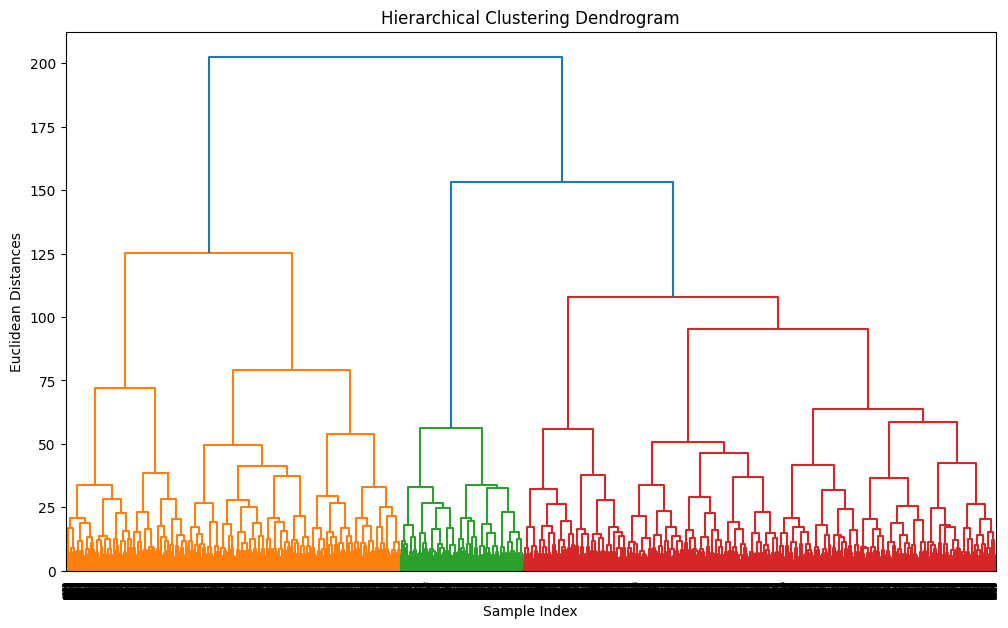

Hierarchical Clustering Silhouette Score: 0.1141


In [50]:
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

# Initialize model
# 'ward' linkage minimizes the variance of the clusters being merged
hc = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')

# Fit and predict
train_clusters_hc = hc.fit_predict(x_train_scaled)

# Add to dataframe
x_train_with_hc = x_train.copy()
x_train_with_hc['HC_Cluster'] = train_clusters_hc

print(f"Cluster assignments: {train_clusters_hc[:5]}")

# Create the Linkage Matrix
linkage_matrix = sch.linkage(x_train_scaled, method='ward')

# Plot the Dendrogram
plt.figure(figsize=(12, 7))
dendrogram = sch.dendrogram(linkage_matrix)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Euclidean Distances')
plt.show()


hc_sil_score = silhouette_score(x_train_scaled, train_clusters_hc)
print(f"Hierarchical Clustering Silhouette Score: {hc_sil_score:.4f}")

# DBSCAN (Density-Based Spatial Clustering)


In [51]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# 1. Initialize and fit DBSCAN
# eps: The maximum distance between two samples for one to be considered as in the neighborhood of the other
# min_samples: The number of samples in a neighborhood for a point to be considered a core point
dbscan = DBSCAN(eps=0.5, min_samples=5)
train_clusters_dbscan = dbscan.fit_predict(x_train_scaled)

# 2. Calculate Silhouette Score
# Silhouette score is only valid if you have more than 1 cluster (excluding noise)
labels = dbscan.labels_
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print(f"Estimated number of clusters: {n_clusters_}")
print(f"Estimated number of noise points: {n_noise_}")

if n_clusters_ > 1:
    score = silhouette_score(x_train_scaled, labels)
    print(f"DBSCAN Silhouette Score: {score:.4f}")
else:
    print("Silhouette Score cannot be calculated: Less than 2 clusters found.")


Estimated number of clusters: 0
Estimated number of noise points: 8461
Silhouette Score cannot be calculated: Less than 2 clusters found.
